In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import (
    train_test_split,
    RandomizedSearchCV,
    KFold
)

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.preprocessing import OneHotEncoder

from sklearn.ensemble import RandomForestRegressor

!pip install catboost
import catboost
print(catboost.__version__)
from catboost import CatBoostRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 9.9 MB/s eta 0:00:00
1.2.10


Dataset shape:
(18278, 104)

Missing Values:
age                            0
height_cm                      0
potential                      0
international_reputation       0
weak_foot                      0
team_position                240
shooting                    2036
dribbling                   2036
passing                     2036
overall                        0
value_eur                      0
dtype: int64

Dataset shape after removing missing values:
(16042, 11)

Number of duplicate rows:
0

Dataset shape after removing duplicates:
(16042, 11)


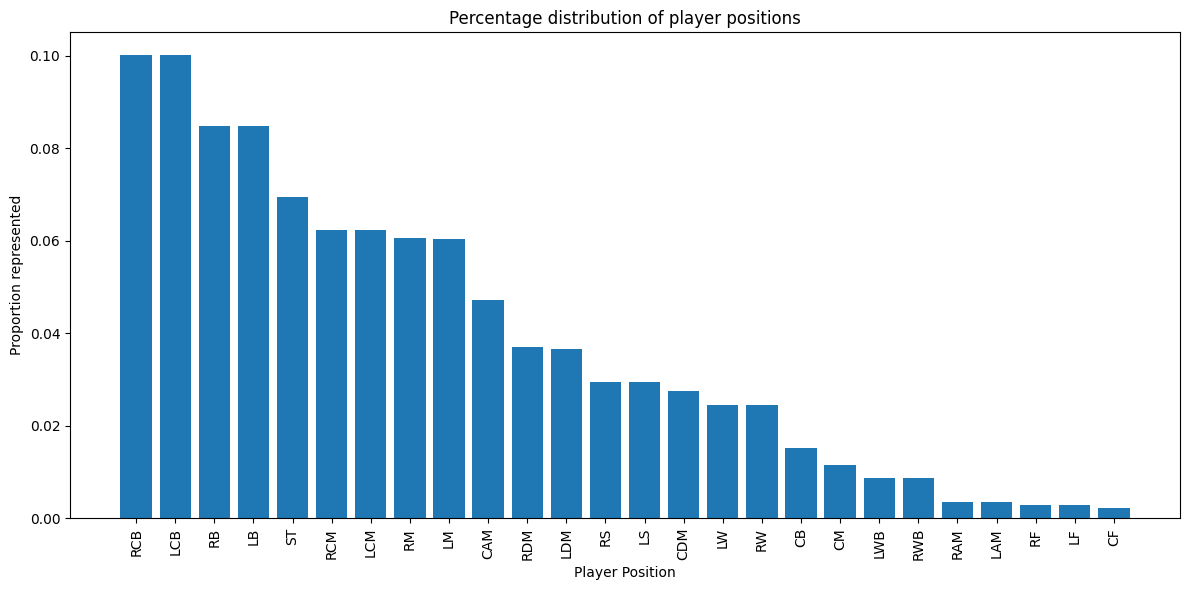

/tmp/ipykernel_552/3623676768.py:115: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'Forwarder' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df.loc[


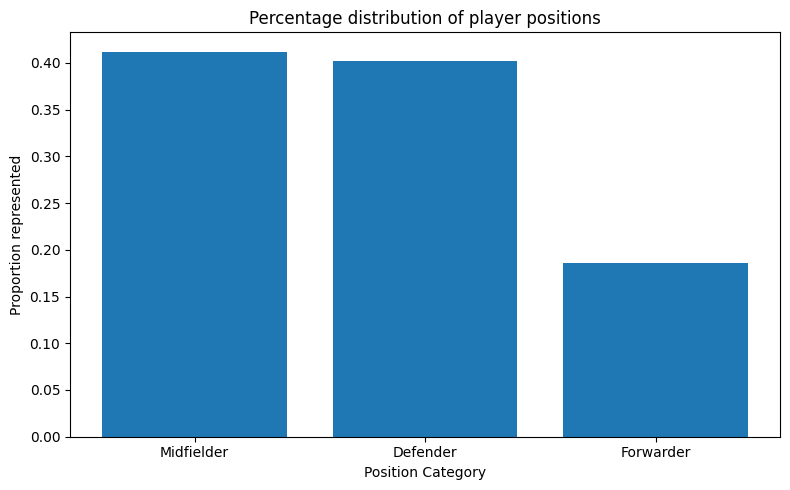


Player Count After Categorization:

position_category
Midfielder    2719
Defender      2656
Forwarder     1223
Name: count, dtype: int64


In [17]:
# Load dataset
df = pd.read_csv('players_20.csv')

# ============================================
# Select required columns only
# ============================================
print("Dataset shape:")
print(df.shape)

features = [
    'age',
    'height_cm',
    'potential',
    'international_reputation',
    'weak_foot',
    'team_position',
    'shooting',
    'dribbling',
    'passing',
    'overall'
]

target = 'value_eur'

df = df[features + [target]]

# ============================================
# Detect missing values
# ============================================

print("\nMissing Values:")
print(df.isnull().sum())

df = df.dropna()

print("\nDataset shape after removing missing values:")
print(df.shape)

# ============================================
# Detect duplicate rows
# ============================================

duplicate_count = df.duplicated().sum()

print("\nNumber of duplicate rows:")
print(duplicate_count)

df = df.drop_duplicates()

print("\nDataset shape after removing duplicates:")
print(df.shape)

# ============================================
# Remove GK, RES, SUB
# ============================================

exclude_positions = ['GK', 'RES', 'SUB']

df = df[
    ~df['team_position'].isin(exclude_positions)
]

# ============================================
# GRAPH 1:
# Before categorization
# ============================================

position_percentage = (
    df['team_position']
    .value_counts(normalize=True)
)

plt.figure(figsize=(12,6))

plt.bar(
    position_percentage.index,
    position_percentage.values
)

plt.title('Percentage distribution of player positions')

plt.xlabel('Player Position')
plt.ylabel('Proportion represented')

plt.xticks(rotation=90)

plt.tight_layout()

plt.show()

# Categorize into 3 groups
forward_positions = [
    'ST', 'LS', 'RS',
    'CF', 'LF', 'RF',
    'LW', 'RW'
]

midfielder_positions = [
    'CAM', 'LAM', 'RAM',
    'CM', 'LCM', 'RCM',
    'CDM', 'LDM', 'RDM',
    'LM', 'RM'
]

defender_positions = [
    'LWB', 'RWB',
    'LB', 'RB',
    'LCB', 'RCB', 'CB'
]

# Create new column
df['position_category'] = np.nan

# Assign categories
df.loc[
    df['team_position'].isin(forward_positions),
    'position_category'
] = 'Forwarder'

df.loc[
    df['team_position'].isin(midfielder_positions),
    'position_category'
] = 'Midfielder'

df.loc[
    df['team_position'].isin(defender_positions),
    'position_category'
] = 'Defender'

# ============================================
# GRAPH 2:
# After categorization
# ============================================

group_percentage = (
    df['position_category']
    .value_counts(normalize=True)
)

plt.figure(figsize=(8,5))

plt.bar(
    group_percentage.index,
    group_percentage.values
)

plt.title('Percentage distribution of player positions')

plt.xlabel('Position Category')
plt.ylabel('Proportion represented')

plt.tight_layout()

plt.show()

# ============================================
# Display categorized player count
# ============================================

print("\nPlayer Count After Categorization:\n")

print(
    df['position_category']
    .value_counts()
)

# EDA Analysis

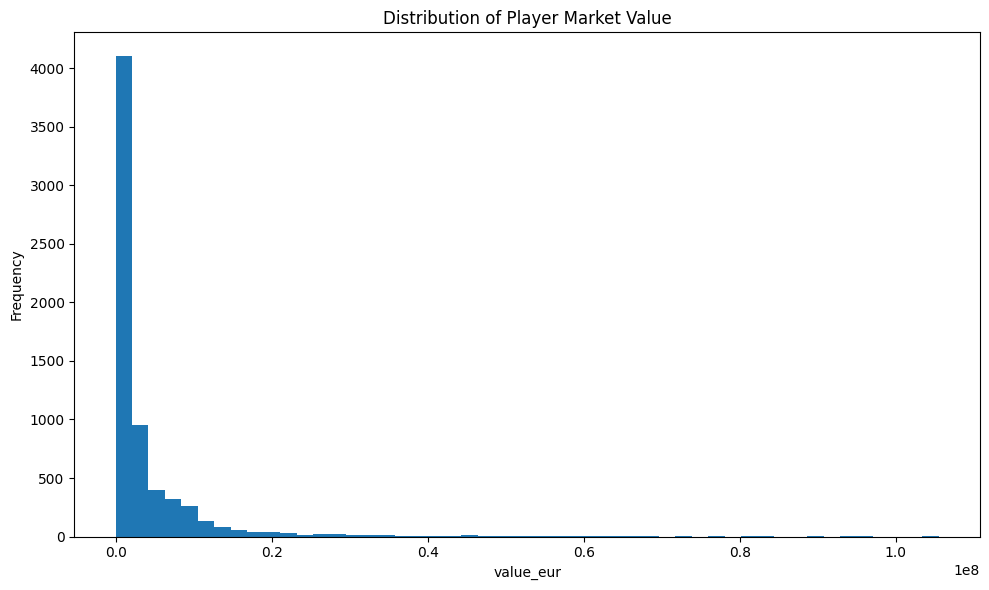

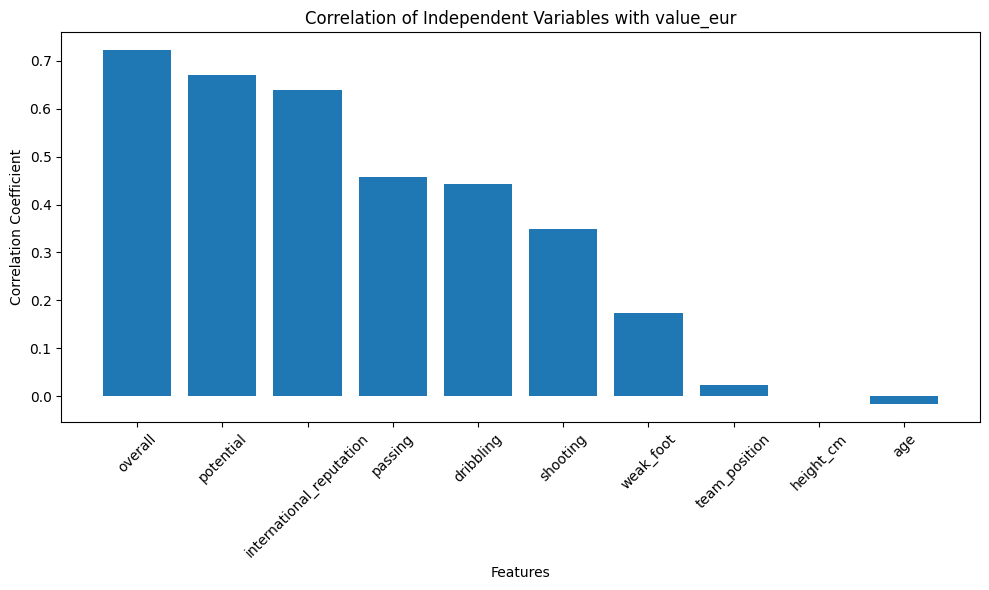

In [3]:
# --------------------------------------------
# Keep only required columns
# --------------------------------------------

eda_df = df[features + [target]].copy()

# --------------------------------------------
# Convert categorical variable
# --------------------------------------------

eda_df['team_position'] = eda_df['team_position'].astype('category').cat.codes

# ============================================
# 1. Distribution of value_eur
# ============================================

plt.figure(figsize=(10,6))

plt.hist(
    eda_df['value_eur'],
    bins=50
)

plt.title('Distribution of Player Market Value')

plt.xlabel('value_eur')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()


# ============================================
# 2. Correlation with target variable
# ============================================

correlation_target = (
    eda_df.corr(numeric_only=True)[target]
    .drop(target)
    .sort_values(ascending=False)
)

plt.figure(figsize=(10,6))

plt.bar(
    correlation_target.index,
    correlation_target.values
)

plt.title('Correlation of Independent Variables with value_eur')

plt.xlabel('Features')
plt.ylabel('Correlation Coefficient')

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


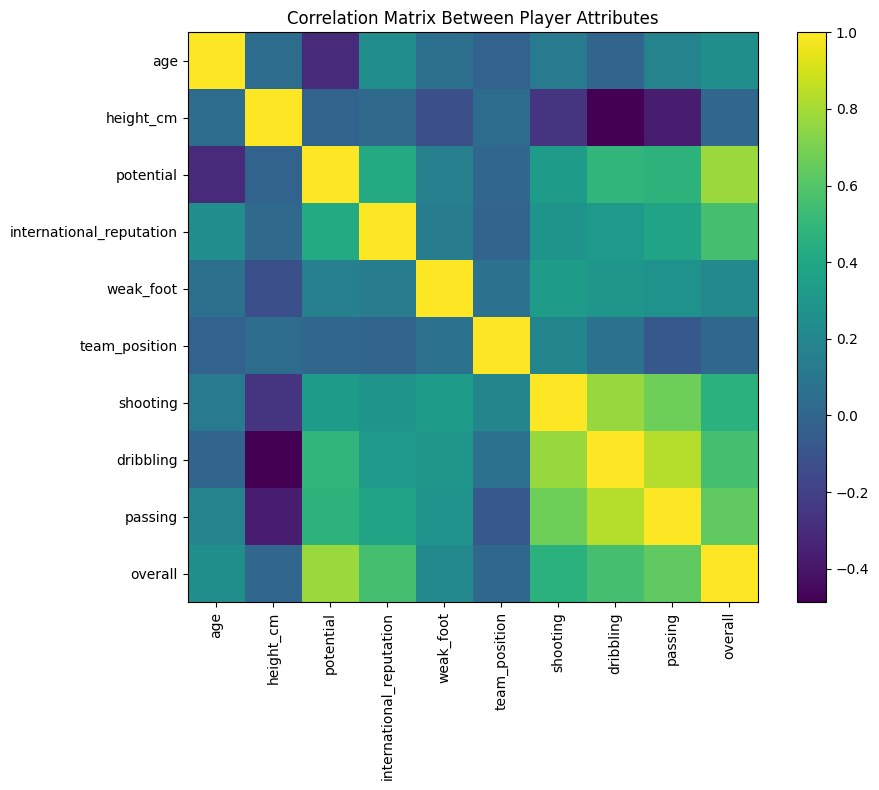

In [4]:
# ============================================
# 3. Correlation matrix between attributes
# ============================================

corr_matrix = eda_df.drop(columns=[target]).corr(numeric_only=True)

plt.figure(figsize=(10,8))

plt.imshow(corr_matrix)

plt.colorbar()

plt.xticks(
    range(len(corr_matrix.columns)),
    corr_matrix.columns,
    rotation=90
)

plt.yticks(
    range(len(corr_matrix.columns)),
    corr_matrix.columns
)

plt.title('Correlation Matrix Between Player Attributes')

plt.tight_layout()
plt.show()

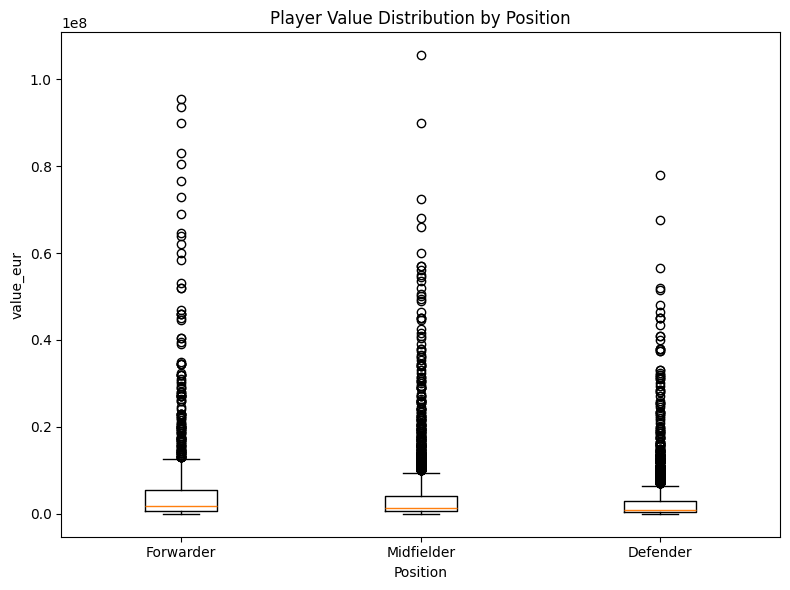

In [14]:
# ============================================
# 4. Boxplot of value_eur by team_position
# ============================================

# Reload original categorized labels
position_df = df.copy()

position_df = position_df[
    position_df['position_category'].isin(
        ['Forwarder', 'Midfielder', 'Defender']
    )
]

groups = [
    position_df[position_df['position_category'] == 'Forwarder']['value_eur'],
    position_df[position_df['position_category'] == 'Midfielder']['value_eur'],
    position_df[position_df['position_category'] == 'Defender']['value_eur']
]

plt.figure(figsize=(8,6))

plt.boxplot(
    groups,
    tick_labels=['Forwarder', 'Midfielder', 'Defender']
)

plt.title('Player Value Distribution by Position')

plt.xlabel('Position')
plt.ylabel('value_eur')

plt.tight_layout()
plt.show()

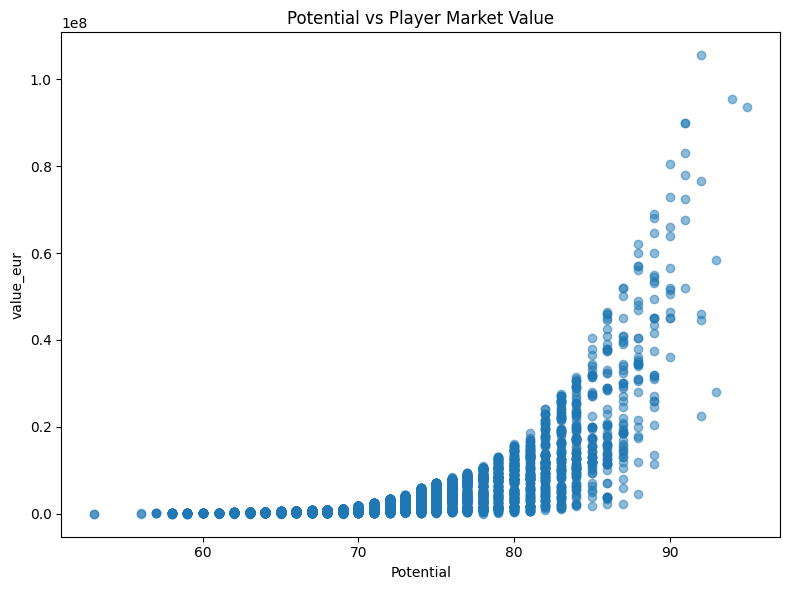

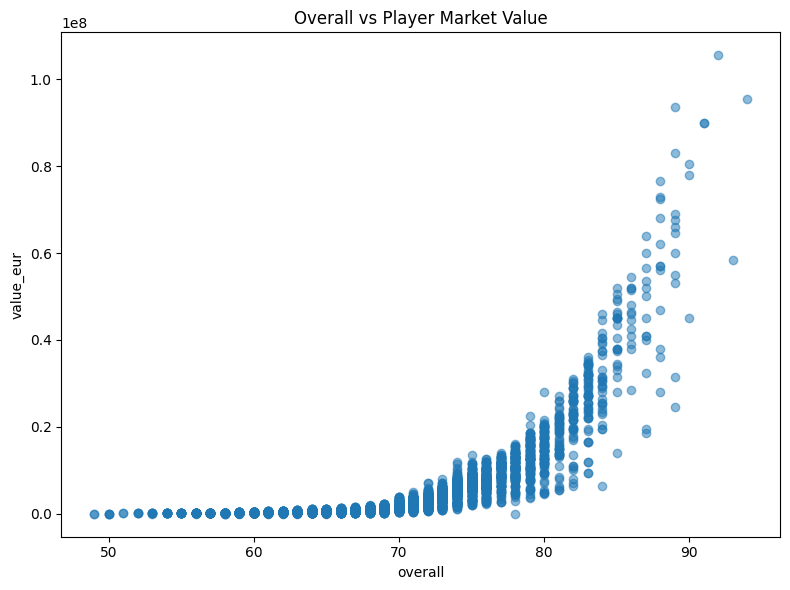

In [15]:
# ============================================
# 5. Scatter plot: potential vs value_eur
# ============================================

plt.figure(figsize=(8,6))

plt.scatter(
    eda_df['potential'],
    eda_df['value_eur'],
    alpha=0.5
)

plt.title('Potential vs Player Market Value')

plt.xlabel('Potential')
plt.ylabel('value_eur')

plt.tight_layout()
plt.show()

# ============================================
# 6. Scatter plot: overall vs value_eur
# ============================================

plt.figure(figsize=(8,6))

plt.scatter(
    eda_df['overall'],
    eda_df['value_eur'],
    alpha=0.5
)

plt.title('Overall vs Player Market Value')

plt.xlabel('overall')
plt.ylabel('value_eur')

plt.tight_layout()
plt.show()

# Random Forest Regression

In [8]:
selected_features = [
    'potential',
    'international_reputation',
    'passing',
    'overall'
]

# ============================================
# Prepare Data
# ============================================

X = df[selected_features]
y = np.log1p(df[target])   # log transform improves prediction


# Train-Test Split (80-20)
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# ============================================
# Preprocessing
# ============================================

numeric_features = [
    'potential',
    'international_reputation',
    'passing',
    'overall'
]

preprocessor = 'passthrough'

# ============================================
# Random Forest Model
# ============================================

rf = RandomForestRegressor(
    random_state=42,
    n_jobs=-1
)

# ============================================
# Pipeline
# ============================================

pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', rf)
])

# ============================================
# Hyperparameter Search Space
# ============================================

param_grid = {
    'model__n_estimators': [200, 300, 400],
    'model__max_depth': [10, 20, 30, None],
    'model__min_samples_split': [2, 5, 10],
    'model__min_samples_leaf': [1, 2, 4],
    'model__max_features': ['sqrt', 'log2']
}

# ============================================
# Cross Validation
# ============================================

cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# ============================================
# Randomized Search
# Faster than GridSearch
# Good balance for Colab runtime
# ============================================

random_search = RandomizedSearchCV(
    estimator=pipeline,
    param_distributions=param_grid,
    n_iter=25,
    scoring='r2',
    cv=cv,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

# ============================================
# Train Model
# ============================================

random_search.fit(X_train, y_train)

# ============================================
# Best Model
# ============================================

best_model = random_search.best_estimator_

print("Best Parameters:\n")
print(random_search.best_params_)

# ============================================
# Predictions
# ============================================

y_pred_log = best_model.predict(X_test)

# Convert back from log scale
y_test_actual = np.expm1(y_test)
y_pred_actual = np.expm1(y_pred_log)

# ============================================
# Evaluation Metrics
# ============================================

mae = mean_absolute_error(
    y_test_actual,
    y_pred_actual
)

rmse = np.sqrt(
    mean_squared_error(
        y_test_actual,
        y_pred_actual
    )
)

r2 = r2_score(
    y_test_actual,
    y_pred_actual
)

# ============================================
# Results
# ============================================

print("\nModel Performance")
print("-------------------------")
print(f"MAE  : {mae:,.2f}")
print(f"RMSE : {rmse:,.2f}")
print(f"R²   : {r2:.4f}")

# ============================================
# Feature Importance
# ============================================

# Get encoded feature names
encoded_features = selected_features

# Get feature importance
importance = best_model.named_steps[
    'model'
].feature_importances_

feature_importance = pd.DataFrame({
    'Feature': encoded_features,
    'Importance': importance
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

print("\nFeature Importance")
print("-------------------------")
print(feature_importance)

Fitting 5 folds for each of 25 candidates, totalling 125 fits
Best Parameters:

{'model__n_estimators': 300, 'model__min_samples_split': 10, 'model__min_samples_leaf': 4, 'model__max_features': 'sqrt', 'model__max_depth': 10}

Model Performance
-------------------------
MAE  : 547,846.36
RMSE : 1,617,813.06
R²   : 0.9567

Feature Importance
-------------------------
                    Feature  Importance
3                   overall    0.554135
0                 potential    0.352646
2                   passing    0.087130
1  international_reputation    0.006090


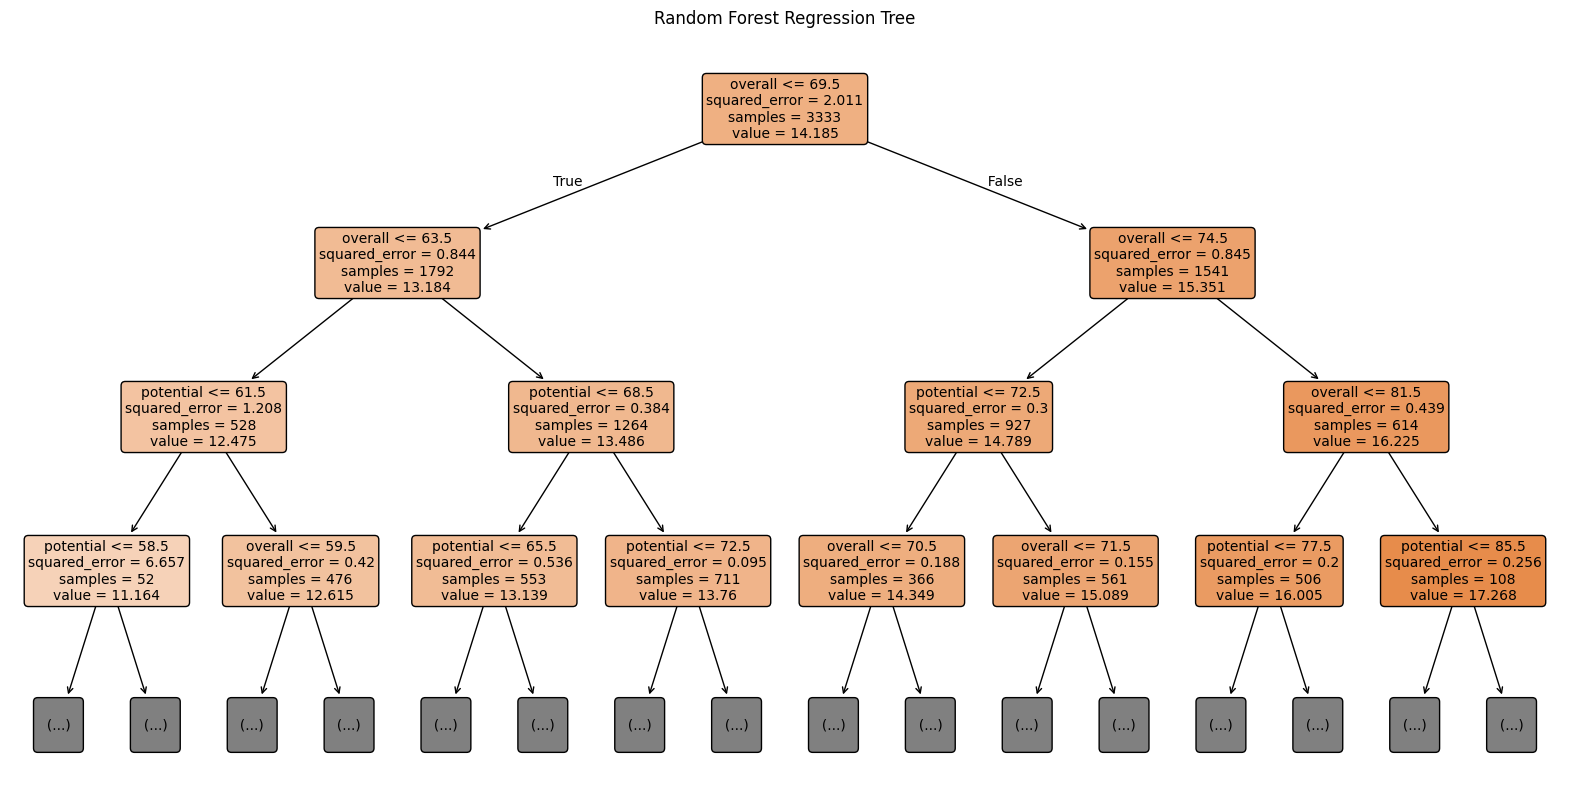

In [9]:
# ============================================
# Visualize One Tree from Random Forest
# ============================================

from sklearn import tree

# --------------------------------------------
# Extract trained Random Forest model
# --------------------------------------------

rf_model = best_model.named_steps['model']

# --------------------------------------------
# Select one tree from the forest
# Example: first tree
# --------------------------------------------

single_tree = rf_model.estimators_[0]

# --------------------------------------------
# Plot tree
# --------------------------------------------

plt.figure(figsize=(20,10))

tree.plot_tree(
    single_tree,
    feature_names=selected_features,
    filled=True,
    rounded=True,
    max_depth=3,   # limit depth for readability
    fontsize=10
)

plt.title('Random Forest Regression Tree')

plt.show()

# Linear Regression

In [13]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression

selected_features = [
    'potential',
    'international_reputation',
    'passing',
    'overall',
    'position_category'
]

# ============================================
# Prepare Data
# ============================================

# Create a temporary dataframe with selected features and target, and drop NaNs
data_for_model = df[selected_features + [target]].dropna()

X = data_for_model[selected_features]
y = np.log1p(data_for_model[target])   # log transform improves prediction


# Train-Test Split (80-20)
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# ============================================
# Preprocessing
# ============================================

numeric_features = [
    'potential',
    'international_reputation',
    'passing',
    'overall'
]

categorical_features = ['position_category']

preprocessor = ColumnTransformer(
    transformers=[
        (
            'num',
            StandardScaler(),
            numeric_features
        ),
        (
            'cat',
            OneHotEncoder(handle_unknown='ignore'),
            categorical_features
        )
    ]
)

# ============================================
# Linear Regression Model
# ============================================

lr = LinearRegression()

# ============================================
# Pipeline
# ============================================

pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', lr)
])

# ============================================
# Train Model
# ============================================

pipeline.fit(X_train, y_train)

# ============================================
# Best Model (now just the trained pipeline)
# ============================================

best_model = pipeline

print("Linear Regression does not involve hyperparameter tuning like Random Forest.")

# ============================================
# Predictions
# ============================================

y_pred_log = best_model.predict(X_test)

# Convert back from log scale
y_test_actual = np.expm1(y_test)
y_pred_actual = np.expm1(y_pred_log)

# ============================================
# Evaluation Metrics
# ============================================

mae = mean_absolute_error(
    y_test_actual,
    y_pred_actual
)

rmse = np.sqrt(
    mean_squared_error(
        y_test_actual,
        y_pred_actual
    )
)

r2 = r2_score(
    y_test_actual,
    y_pred_actual
)

# ============================================
# Results
# ============================================

print("\nModel Performance")
print("-------------------------")
print(f"MAE  : {mae:,.2f}")
print(f"RMSE : {rmse:,.2f}")
print(f"R²   : {r2:.4f}")

# ============================================
# Feature Importance (Coefficients for Linear Regression)
# ============================================

feature_names = best_model.named_steps[
    'preprocessor'
].get_feature_names_out()

coefficients = best_model.named_steps[
    'model'
].coef_

intercept = best_model.named_steps[
    'model'
].intercept_

feature_importance = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients
})

feature_importance['Abs_Coefficient'] = (
    feature_importance['Coefficient'].abs()
)

feature_importance = feature_importance.sort_values(
    by='Abs_Coefficient',
    ascending=False
)

print("\nCoefficients (Standardized Feature Importance)")
print("---------------------------------------------")

print(
    feature_importance[
        ['Feature', 'Coefficient']
    ]
)

print(f"\nIntercept: {intercept:.4f}")

Linear Regression does not involve hyperparameter tuning like Random Forest.

Model Performance
-------------------------
MAE  : 802,081.21
RMSE : 2,547,472.99
R²   : 0.8927

Coefficients (Standardized Feature Importance)
---------------------------------------------
                             Feature  Coefficient
3                       num__overall     0.978563
0                     num__potential     0.445027
4    cat__position_category_Defender    -0.111926
1      num__international_reputation    -0.090349
5   cat__position_category_Forwarder     0.076862
6  cat__position_category_Midfielder     0.035064
2                       num__passing    -0.022389

Intercept: 14.2268


# CatBoost

In [10]:
df_cat = df.copy()

# 1. NEW FEATURE COMBINATIONS
df_cat['shooting_per_overall'] = df_cat['shooting'] / df_cat['overall']
df_cat['dribbling_per_overall'] = df_cat['dribbling'] / df_cat['overall']
df_cat['passing_per_overall'] = df_cat['passing'] / df_cat['overall']

df_cat['growth_margin'] = df_cat['potential'] - df_cat['overall']
df_cat['age_to_potential_ratio'] = df_cat['age'] / df_cat['potential']

# Fill any potential NaNs created by division
df_cat = df_cat.fillna(0)

# 2. SELECT FEATURES (Added height, weak_foot, raw skills, and position)
cat_model_features = [
    'age',
    'height_cm',
    'potential',
    'international_reputation',
    'weak_foot',
    'position_category', # Categorical feature
    'overall',
    'shooting_per_overall',
    'dribbling_per_overall',
    'passing_per_overall',
    'growth_margin',          # Strategic investment feature
    'age_to_potential_ratio'  # Strategic investment feature
]

X_c = df_cat[cat_model_features]
y_c = np.log1p(df_cat[target])

# Identify indices of categorical features for CatBoost
categorical_indices = ['position_category']

# 3. SPLIT DATA
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_c, y_c, test_size=0.2, random_state=42
)

# 4. INITIALIZE CATBOOST WITH HYPERPARAMETER TUNING
# Using a parameter grid to find the optimal combination
cat_param_grid = {
    'depth': [6, 8, 10],
    'learning_rate': [0.03, 0.05, 0.1],
    'l2_leaf_reg': [1, 3, 5],
    'iterations': [1000]
}

# Remove cat_features from the constructor
cat_base = CatBoostRegressor(
    eval_metric='RMSE',
    random_seed=42,
    verbose=False
)

cat_random_search = RandomizedSearchCV(
    estimator=cat_base,
    param_distributions=cat_param_grid,
    n_iter=10,
    scoring='r2',
    cv=3,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

# 5. TRAIN & TUNE
print("\n🚀 Tuning and Training CatBoost...\n")
# Pass cat_features to the fit method
cat_random_search.fit(X_train_c, y_train_c, cat_features=categorical_indices)

best_cat_model = cat_random_search.best_estimator_
print("Best CatBoost Parameters:", cat_random_search.best_params_)

# 6. PREDICT & EVALUATE
y_pred_log_c = best_cat_model.predict(X_test_c)

# Convert predictions back to actual Euros
y_pred_actual_c = np.expm1(y_pred_log_c)
y_test_actual_c = np.expm1(y_test_c)

cat_mae_iso = mean_absolute_error(y_test_actual_c, y_pred_actual_c)
cat_rmse_iso = np.sqrt(mean_squared_error(y_test_actual_c, y_pred_actual_c))
cat_r2_iso = r2_score(y_test_actual_c, y_pred_actual_c)

print(f"\nCatBoost Evolution (Isolated) Results:")
print(f"MAE:  {cat_mae_iso:,.2f}")
print(f"RMSE: {cat_rmse_iso:,.2f}")
print(f"R²:   {cat_r2_iso:.4f}")


🚀 Tuning and Training CatBoost...

Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best CatBoost Parameters: {'learning_rate': 0.03, 'l2_leaf_reg': 1, 'iterations': 1000, 'depth': 6}

CatBoost Evolution (Isolated) Results:
MAE:  126,592.64
RMSE: 719,215.32
R²:   0.9914


# XGBoost


In [11]:
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd

# =========================
# 1. FEATURE ENGINEERING
# =========================
df_xgb = df.copy()

df_xgb['shooting_per_overall'] = df_xgb['shooting'] / df_xgb['overall']
df_xgb['dribbling_per_overall'] = df_xgb['dribbling'] / df_xgb['overall']
df_xgb['passing_per_overall'] = df_xgb['passing'] / df_xgb['overall']

df_xgb['growth_margin'] = df_xgb['potential'] - df_xgb['overall']
df_xgb['age_to_potential_ratio'] = df_xgb['age'] / df_xgb['potential']

# Fill NaN values
df_xgb = df_xgb.fillna(0)

# =========================
# 2. SELECT FEATURES
# =========================
xgb_model_features = [
    'age',
    'height_cm',
    'potential',
    'international_reputation',
    'weak_foot',
    'position_category',   # categorical
    'overall',
    'shooting_per_overall',
    'dribbling_per_overall',
    'passing_per_overall',
    'growth_margin',
    'age_to_potential_ratio'
]

X_xgb = df_xgb[xgb_model_features]
y_xgb = np.log1p(df_xgb[target])

# =========================
# 3. ENCODE CATEGORICAL FEATURE
# =========================
X_xgb = pd.get_dummies(
    X_xgb,
    columns=['position_category'],
    drop_first=True
)

# =========================
# 4. TRAIN TEST SPLIT
# =========================
X_train_xgb, X_test_xgb, y_train_xgb, y_test_xgb = train_test_split(
    X_xgb,
    y_xgb,
    test_size=0.2,
    random_state=42
)

# =========================
# 5. XGBOOST + HYPERPARAMETER TUNING
# =========================
xgb_param_grid = {
    'n_estimators': [300, 500, 800],
    'max_depth': [4, 6, 8],
    'learning_rate': [0.03, 0.05, 0.1],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0],
    'reg_alpha': [0, 0.1, 1],
    'reg_lambda': [1, 3, 5]
}

xgb_base = XGBRegressor(
    objective='reg:squarederror',
    random_state=42,
    n_jobs=-1
)

xgb_random_search = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=xgb_param_grid,
    n_iter=10,
    scoring='r2',
    cv=3,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

# =========================
# 6. TRAIN & TUNE
# =========================
print("\n🚀 Tuning and Training XGBoost...\n")

xgb_random_search.fit(X_train_xgb, y_train_xgb)

best_xgb_model = xgb_random_search.best_estimator_

print("Best XGBoost Parameters:")
print(xgb_random_search.best_params_)

# =========================
# 7. PREDICT & EVALUATE
# =========================
y_pred_log_xgb = best_xgb_model.predict(X_test_xgb)

# Convert back to actual Euro values
y_pred_actual_xgb = np.expm1(y_pred_log_xgb)
y_test_actual_xgb = np.expm1(y_test_xgb)

xgb_mae = mean_absolute_error(y_test_actual_xgb, y_pred_actual_xgb)
xgb_rmse = np.sqrt(mean_squared_error(y_test_actual_xgb, y_pred_actual_xgb))
xgb_r2 = r2_score(y_test_actual_xgb, y_pred_actual_xgb)

print(f"\nXGBoost Results:")
print(f"MAE:  {xgb_mae:,.2f}")
print(f"RMSE: {xgb_rmse:,.2f}")
print(f"R²:   {xgb_r2:.4f}")


🚀 Tuning and Training XGBoost...

Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best XGBoost Parameters:
{'subsample': 1.0, 'reg_lambda': 3, 'reg_alpha': 0.1, 'n_estimators': 800, 'max_depth': 4, 'learning_rate': 0.1, 'colsample_bytree': 1.0}

XGBoost Results:
MAE:  130,628.21
RMSE: 782,136.88
R²:   0.9899
